In [6]:
import numpy as np
import gstools as gs


def generate_true_beta_surfaces(field_size=40, seed=0):
    """
    Generate two 'true' beta surfaces on a field_size x field_size grid.
    
    Returns
    -------
    surfaces : dict
        {
            "beta_uniform_2d":  (field_size, field_size),
            "beta_nonuniform_2d": (field_size, field_size),
            "beta_uniform_1d":  (field_size**2,),  # row-major
            "beta_nonuniform_1d": (field_size**2,)
        }
    """
    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------------
    # 1. Grid definition
    # ------------------------------------------------------------------
    x = np.arange(field_size)
    y = np.arange(field_size)

    # for making spatially varying weights later
    xx, yy = np.meshgrid(x, y, indexing="xy")

    # ------------------------------------------------------------------
    # 2. Uniform rate-of-change surface (stationary GRF)
    #    - Single length scale everywhere
    # ------------------------------------------------------------------
    len_uniform = 100.0  # choose any value you like
    model_uniform = gs.Gaussian(
        dim=2,
        var=1.0,
        len_scale=len_uniform,
    )

    srf_uniform = gs.SRF(
        model_uniform,
        mean=0.0,
        seed=int(rng.integers(0, 1_000_000_000))
    )

    # structured() returns a 2D field_size x field_size array
    beta_uniform_2d = srf_uniform.structured([x, y])

    # standardize (optional, just to have comparable scale)
    beta_uniform_2d = (beta_uniform_2d - beta_uniform_2d.mean()) / beta_uniform_2d.std()

    # ------------------------------------------------------------------
    # 3. Non-uniform rate-of-change surface
    #    Idea: mix a smooth and a rough field with spatially varying weight
    #    Z_non(s) = Z_smooth(s) + w(s) * Z_rough(s)
    #    - left side: w ~ 0  → mainly smooth
    #    - right side: w ~ 1 → smooth + rough
    # ------------------------------------------------------------------

    # 3.1 Smooth component (same as uniform, or slightly different len)
    len_smooth = 50.0
    model_smooth = gs.Gaussian(
        dim=2,
        var=1.0,
        len_scale=len_smooth,
    )
    srf_smooth = gs.SRF(
        model_smooth,
        mean=0.0,
        seed=int(rng.integers(0, 1_000_000_000))
    )
    field_smooth_2d = srf_smooth.structured([x, y])

    # 3.2 Rough component (short length scale)
    len_rough = 5.0
    model_rough = gs.Gaussian(
        dim=2,
        var=1.0,
        len_scale=len_rough,
    )
    srf_rough = gs.SRF(
        model_rough,
        mean=0.0,
        seed=int(rng.integers(0, 1_000_000_000))
    )
    field_rough_2d = srf_rough.structured([x, y])

    # 3.3 Spatially varying mixing weight w(s)
    #     - range [0, 1]
    #     - here: increases from left (x=0) to right (x=max)
    w = (xx / (field_size - 1)) ** 2   # quadratic to exaggerate difference

    # 3.4 Construct non-uniform surface
    beta_nonuniform_2d = field_smooth_2d + w * field_rough_2d

    # standardize (optional)
    beta_nonuniform_2d = (beta_nonuniform_2d - beta_nonuniform_2d.mean()) / beta_nonuniform_2d.std()

    # ------------------------------------------------------------------
    # 4. Also return flattened versions (if you use 1D beta in your code)
    # ------------------------------------------------------------------
    beta_uniform_1d = beta_uniform_2d.ravel(order="C")
    beta_nonuniform_1d = beta_nonuniform_2d.ravel(order="C")

    return {
        "beta_uniform_2d": beta_uniform_2d,
        "beta_nonuniform_2d": beta_nonuniform_2d,
        "beta_uniform_1d": beta_uniform_1d,
        "beta_nonuniform_1d": beta_nonuniform_1d,
    }


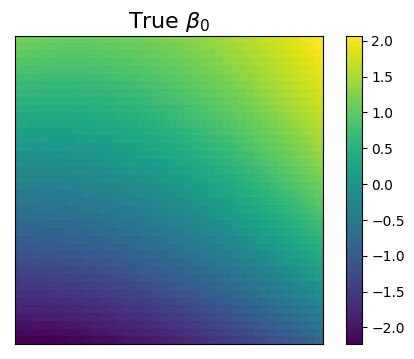

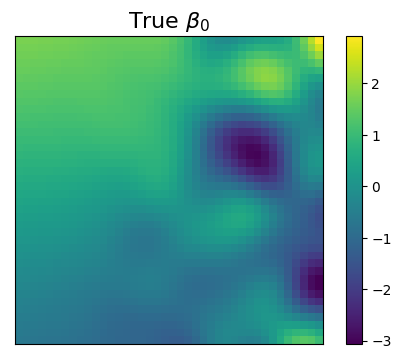

In [7]:

from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset

k = 1
field_size = 40
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 10]
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(
    X, beta
)


surfaces = generate_true_beta_surfaces(field_size=40, seed=42)
beta_u = surfaces["beta_uniform_2d"].reshape(-1, 1)
beta_nu = surfaces["beta_nonuniform_2d"].reshape(-1, 1)
# you can plug beta_u.ravel() or beta_nu.ravel() into your LGWR/MGWR simulator


dataset.plot(
    b=beta_u.T,
    sub_title=[
        r"True $\beta_0$",
    ],
    size=field_size
)
dataset.plot(
    b=beta_nu.T,
    sub_title=[
        r"True $\beta_0$",
    ],
    size=field_size
)

In [8]:
import numpy as np
from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW
from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

In [11]:
g_X = dataset.X[:, 1:]
g_y = dataset.y.reshape(-1, 1)
print(X.shape)
print(g_X.shape, g_y.shape)
# g_coords = dataset.coordinates.tolist()
# gwr_selector = Sel_BW(
#     g_coords, 
#     g_y, 
#     g_X
# )
# global_optimal_bandwidth = gwr_selector.search(bw_min=2)
# official_gwr = OfficialGWR(
#     g_coords, 
#     g_y, 
#     g_X, 
#     global_optimal_bandwidth
# ).fit()

(1600, 2)
(1600, 1) (1600, 1)
